# 05 - Evaluation: Experimental Schemas Comparison - Presentation Slides

## Import libraries and set the paths

In [1]:
from __future__ import annotations

import IPython.display as ipd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from myocardial_infarction_mortality.config import MODELS_DIR, FIGURES_DIR
from myocardial_infarction_mortality.evaluation.visual_evaluation import plot_model_distribution
from myocardial_infarction_mortality.evaluation.statistical_test_evaluation import compute_pairwise_corrected_resampled_ttest

2026-04-19 18:19:46.798 | INFO     | myocardial_infarction_mortality.config:<module>:16 - PROJ_ROOT path is: D:\2_UNIVERSITA\2_MAGISTRALE\1_ANNO\6_MACHINE_LEARNING\2-2023-2024\4-PROJECT\Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction


In [2]:
EXPERIMENTS_NAME = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
}

In [3]:
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR = FIGURES_DIR / "EV_experimental_schemas_comparison_presentation"
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [5]:
all_frames = []

print(f"{'='*80}\nLOADING EXPERIMENTAL SCHEMAS\n{'='*80}")

for folder_name, schema_label in EXPERIMENTS_NAME.items():
    experiment_path = MODELS_DIR / folder_name

    # 1. Verify Folder Exists
    if not experiment_path.exists():
        print(f"[WARNING] Experiment folder not found: {folder_name}")
        continue

    # 2. Find Results Files (Recursively)
    # Looking for 'generalization_metrics_summary.csv' inside any model subfolder
    files = list(experiment_path.glob("**/generalization_metrics_summary.csv"))

    if not files:
        print(f"[SKIP] No results files found for schema: {schema_label}")
        continue

    print(f"Loading '{schema_label}' ({len(files)} files found)...")

    # 3. Load and Process Each File
    for f in files:
        try:
            df_temp = pd.read_csv(f)

            # A. Rename original 'model' to 'model_no_alias'
            df_temp.rename(columns={"model": "model_no_alias"}, inplace=True)

            # B. Create the NEW 'model' column (Concatenation)
            # Format: "ModelName (Alias)" -> e.g. "XGBoost (Cost-Sensitive)"
            df_temp["model"] = df_temp["model_no_alias"] + " (" + schema_label + ")"

            # C. Maintain experiment_name (Explicit check, though likely present)
            # If the CSV didn't have it, we could infer it from folder_name,
            # but usually it is already in the results file.
            if "experiment_name" not in df_temp.columns:
                df_temp["experiment_name"] = folder_name

            # D. Track schema label explicitly (optional, but good for filtering)
            df_temp["learning_schema"] = schema_label

            all_frames.append(df_temp)

        except Exception as e:
            print(f"  [ERROR] Could not read file {f.name}: {e}")

# --- 4. CONCATENATE MASTER DATAFRAME ---
generalization_df = pd.DataFrame()
if all_frames:
    generalization_df = pd.concat(all_frames, ignore_index=True)

    print("\n" + "="*80)
    print("SUCCESS: MASTER DATAFRAME CREATED")
    print("="*80)
    print(f"Total Evaluation Rows Loaded: {len(generalization_df)}")
    print(f"Total Unique Models (Tagged): {generalization_df['model'].nunique()}")

    # Validation: Preview the specific columns we modified
    print("\nPreview of Key Columns:")
    print(generalization_df[["experiment_name", "model_no_alias", "model"]].head())

else:
    print("\n[ERROR] No data loaded. Please check your MODELS_DIR path and folder names.")

LOADING EXPERIMENTAL SCHEMAS
Loading 'Baseline' (12 files found)...
Loading 'Balanced + STD' (12 files found)...
Loading 'Cost-sensitive + STD' (12 files found)...
Loading 'SMOTE + STD' (12 files found)...
Loading 'Balanced + MEC' (12 files found)...
Loading 'Cost-sensitive + MEC' (12 files found)...
Loading 'SMOTE + MEC' (12 files found)...

SUCCESS: MASTER DATAFRAME CREATED
Total Evaluation Rows Loaded: 8400
Total Unique Models (Tagged): 84

Preview of Key Columns:
      experiment_name          model_no_alias  \
0  baseline__standard  DecisionTreeClassifier   
1  baseline__standard  DecisionTreeClassifier   
2  baseline__standard  DecisionTreeClassifier   
3  baseline__standard  DecisionTreeClassifier   
4  baseline__standard  DecisionTreeClassifier   

                               model  
0  DecisionTreeClassifier (Baseline)  
1  DecisionTreeClassifier (Baseline)  
2  DecisionTreeClassifier (Baseline)  
3  DecisionTreeClassifier (Baseline)  
4  DecisionTreeClassifier (Baseline)  

In [6]:
generalization_df

,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
0,baseline__standard,1,1,DecisionTreeClassifier,generalization,4,131,2,21,0.854430,0.666667,0.160000,0.258065,0.984962,0.015038,0.572481,0.396981,0.276792,0.209656,0.572481,0.239578,1.341772,0.046126,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
1,baseline__standard,1,2,DecisionTreeClassifier,generalization,7,131,1,19,0.873418,0.875000,0.269231,0.411765,0.992424,0.007576,0.630828,0.516905,0.442499,0.362389,0.674971,0.397733,1.208861,0.044497,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
2,baseline__standard,1,3,DecisionTreeClassifier,generalization,4,129,3,21,0.847134,0.571429,0.160000,0.250000,0.977273,0.022727,0.568636,0.395428,0.243359,0.193838,0.633182,0.250008,1.356688,0.043970,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
3,baseline__standard,1,4,DecisionTreeClassifier,generalization,3,129,3,22,0.840764,0.500000,0.120000,0.193548,0.977273,0.022727,0.548636,0.342451,0.185645,0.140574,0.696970,0.307331,1.420382,0.043974,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
4,baseline__standard,1,5,DecisionTreeClassifier,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.649545,0.361593,1.273885,0.044501,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


In [7]:
models_to_analyze = ["LogisticRegression",
                     "RandomForestClassifier",
                     "XGBClassifier",
                     "VotingClassifier",
                     "StackingClassifier",
                     "KNORAE",
                     "DESKL",
                     "METADES",
                     ]
print(f"Selected models:\n\t{models_to_analyze}")

generalization_df = generalization_df[generalization_df["model_no_alias"].isin(models_to_analyze)]
generalization_df

Selected models:
	['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier', 'VotingClassifier', 'StackingClassifier', 'KNORAE', 'DESKL', 'METADES']


,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
100,baseline__standard,1,1,DESKL,generalization,3,132,1,22,0.854430,0.750000,0.120000,0.206897,0.992481,0.007519,0.556241,0.345105,0.261328,0.170698,0.764812,0.414571,1.398734,0.250332,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
101,baseline__standard,1,2,DESKL,generalization,8,131,1,18,0.879747,0.888889,0.307692,0.457143,0.992424,0.007576,0.650058,0.552595,0.480119,0.406954,0.796329,0.600120,1.145570,0.166502,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
102,baseline__standard,1,3,DESKL,generalization,3,132,0,22,0.859873,1.000000,0.120000,0.214286,1.000000,0.000000,0.560000,0.346410,0.320713,0.186528,0.871212,0.580750,1.401274,0.148144,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
103,baseline__standard,1,4,DESKL,generalization,0,130,2,25,0.828025,0.000000,0.000000,0.000000,0.984848,0.015152,0.492424,0.000000,-0.049435,-0.024160,0.873030,0.518707,1.605096,0.224802,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
104,baseline__standard,1,5,DESKL,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.779697,0.586524,1.273885,0.099766,157,"['num_standard_scaler__AGE', 'num_standard_sca...",DESKL (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


## Slide 1 - Baseline vs Standard Threshold Approach: F1-score / Precision / Recall / Average Cost

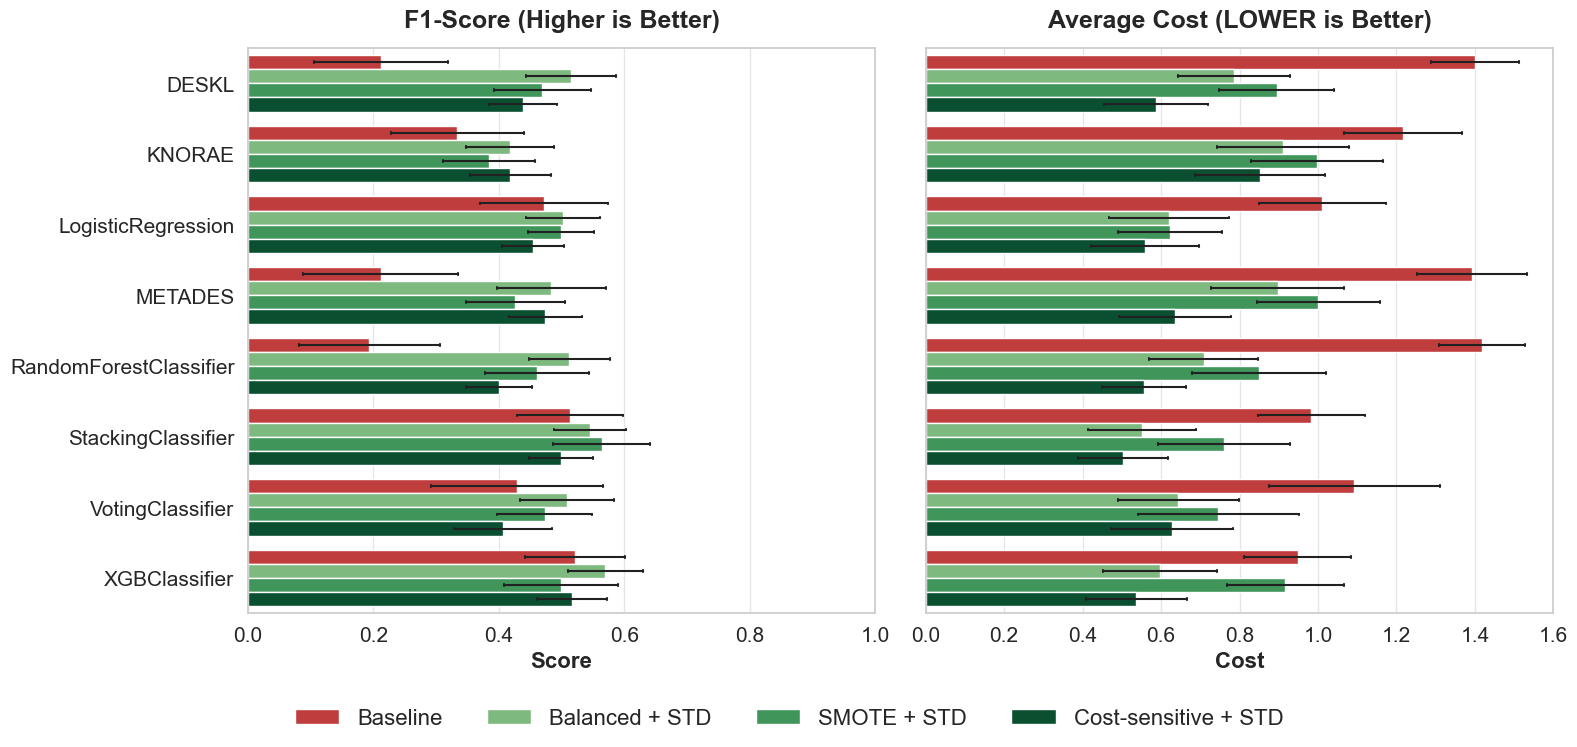

In [8]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

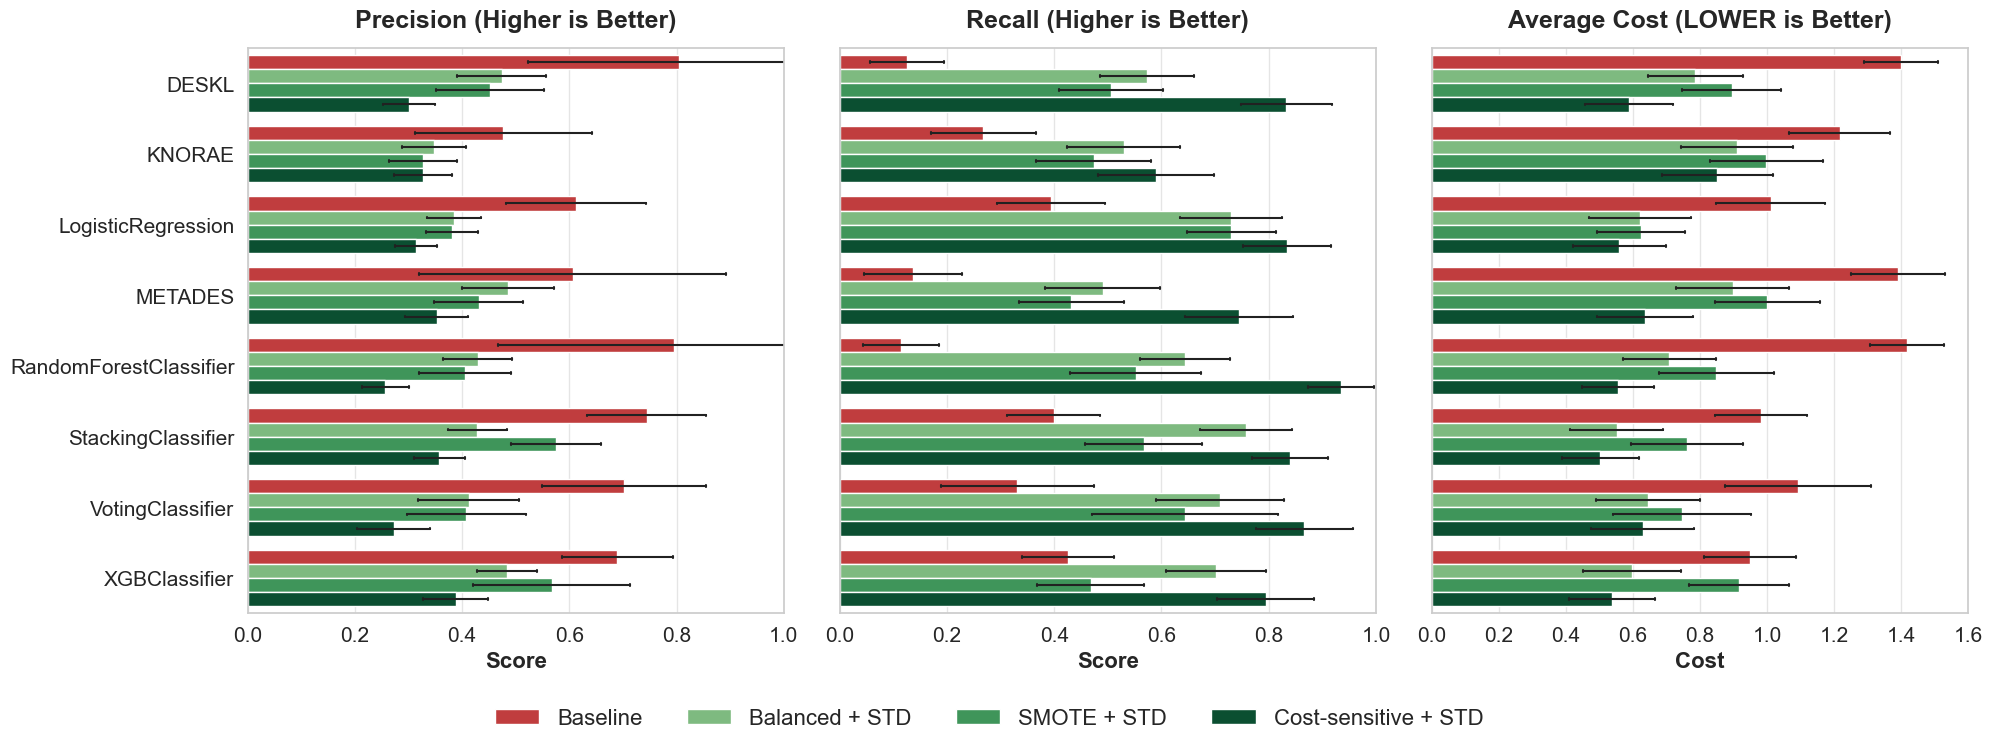

In [9]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Added "f1" to metrics and corresponding title
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)

    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)


    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 2 - Baseline vs MEC Threshold Approach: F1-score / Precision / Recall / Average Cost

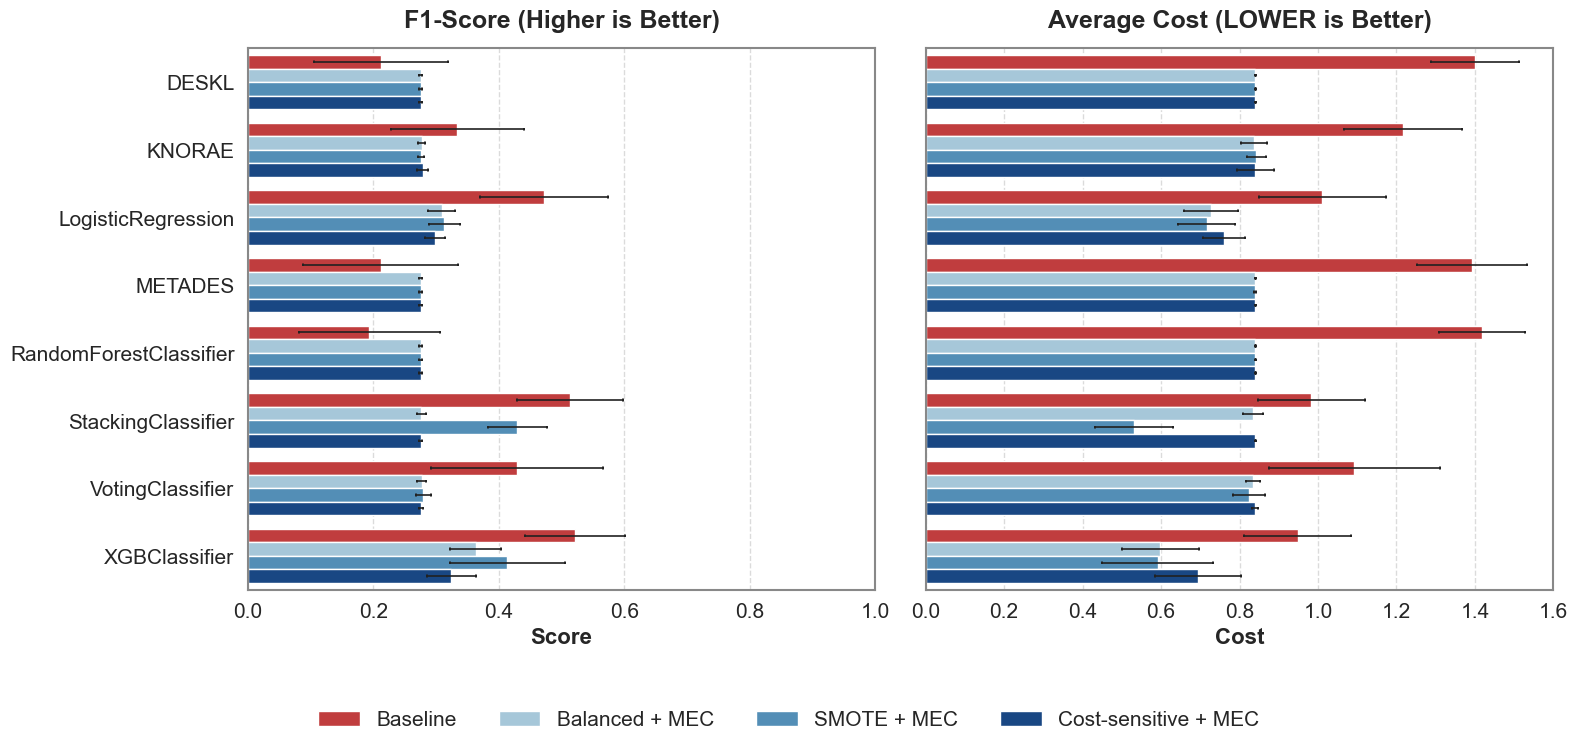

In [10]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

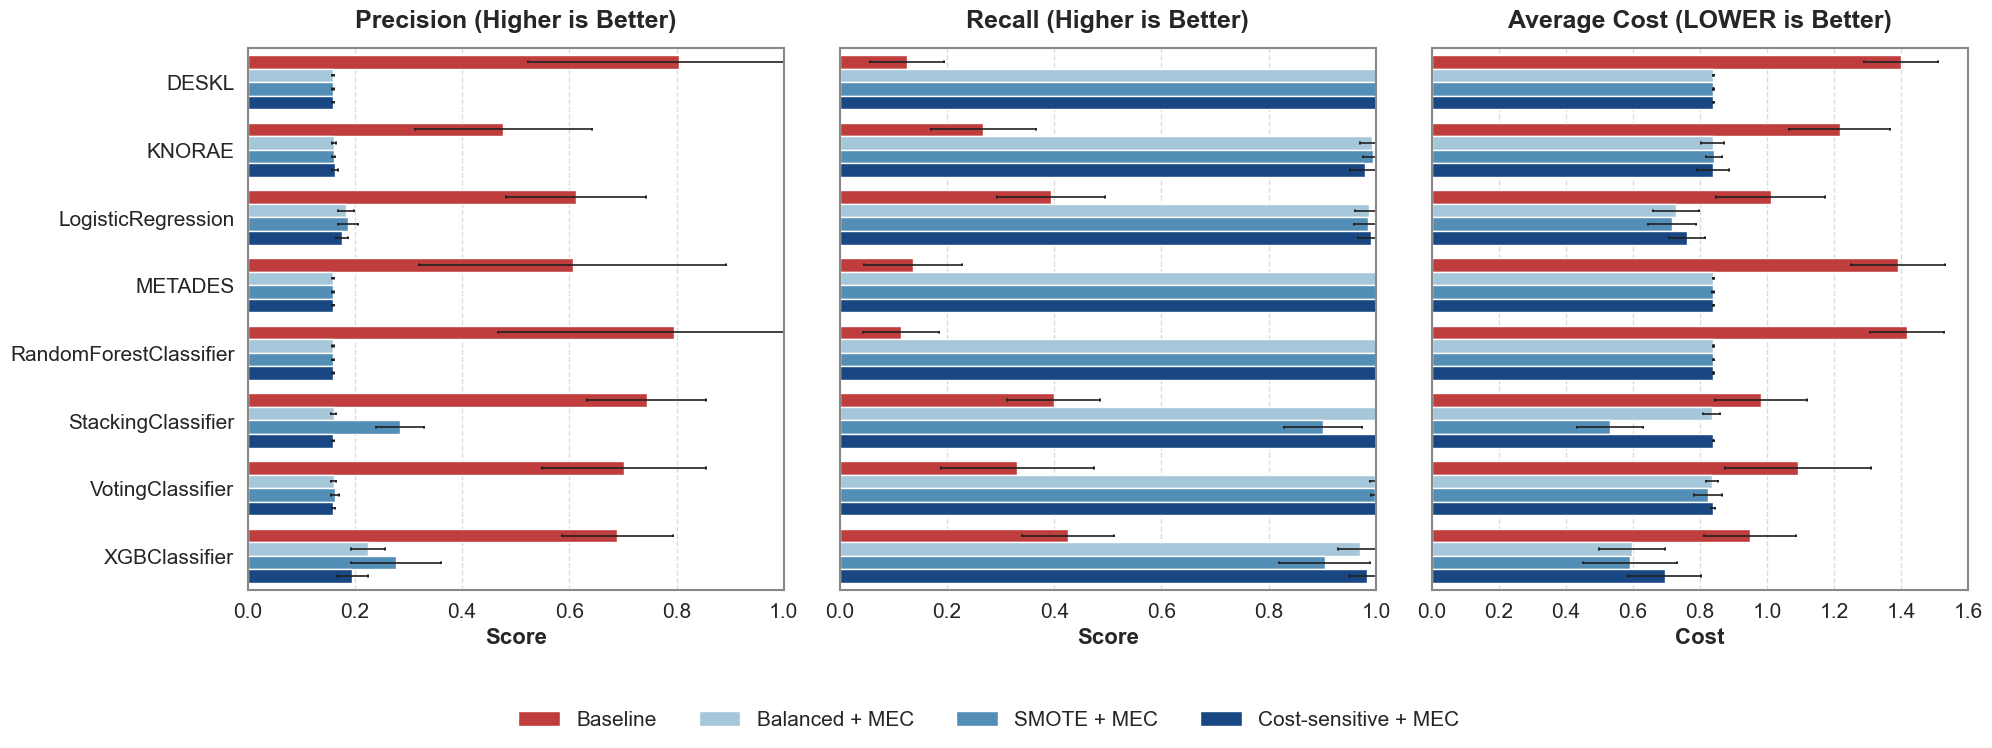

In [11]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 3 - All Experimental Approaches: F1-score / Precision / Recall / Average Cost

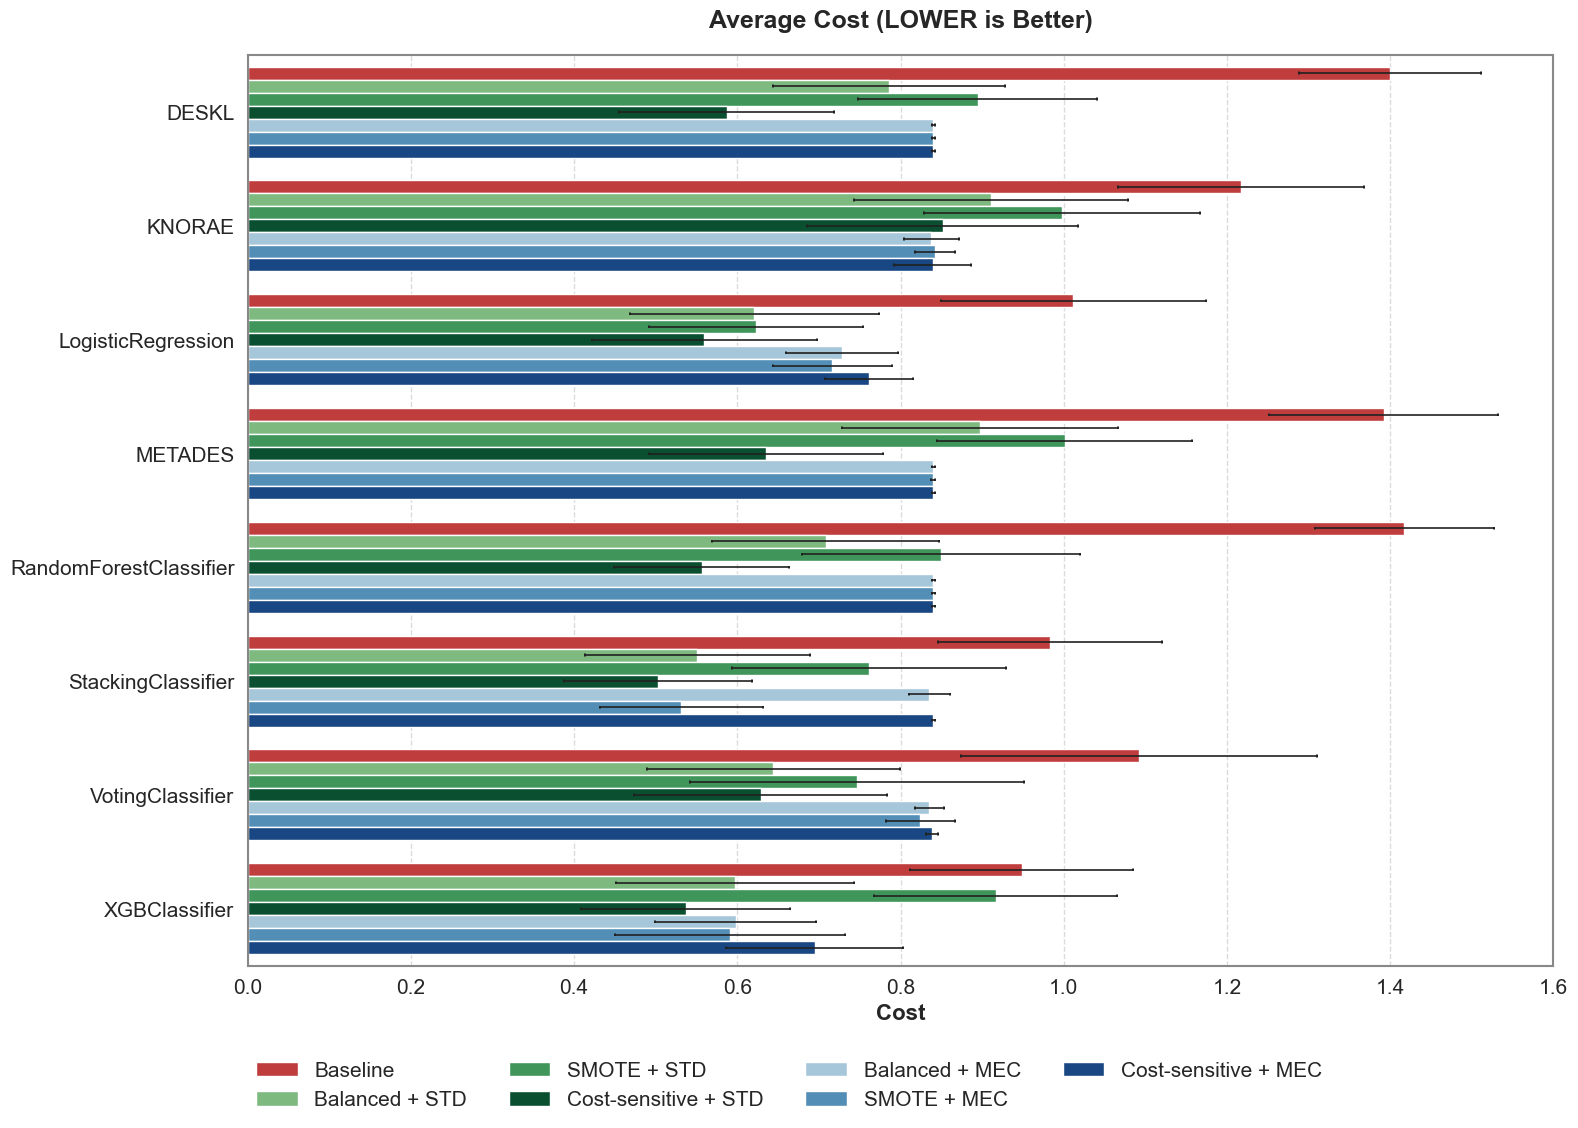

In [12]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, ax = plt.subplots(figsize=(16, 12))

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

sns.barplot(
    data=df_slide3,
    x="average_cost",
    y="model_no_alias",
    hue="experiment_name",
    ax=ax,
    palette=colors_all,
    errorbar="sd",
    capsize=0.08,
    err_kws={"linewidth": 1.2, "color": "#212121"}
)

ax.set_title("Average Cost (LOWER is Better)", fontweight="bold", pad=20)
ax.set_xlabel("Cost", fontweight="bold")
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#888888')
    spine.set_linewidth(1.5)

ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(0, 1.6)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

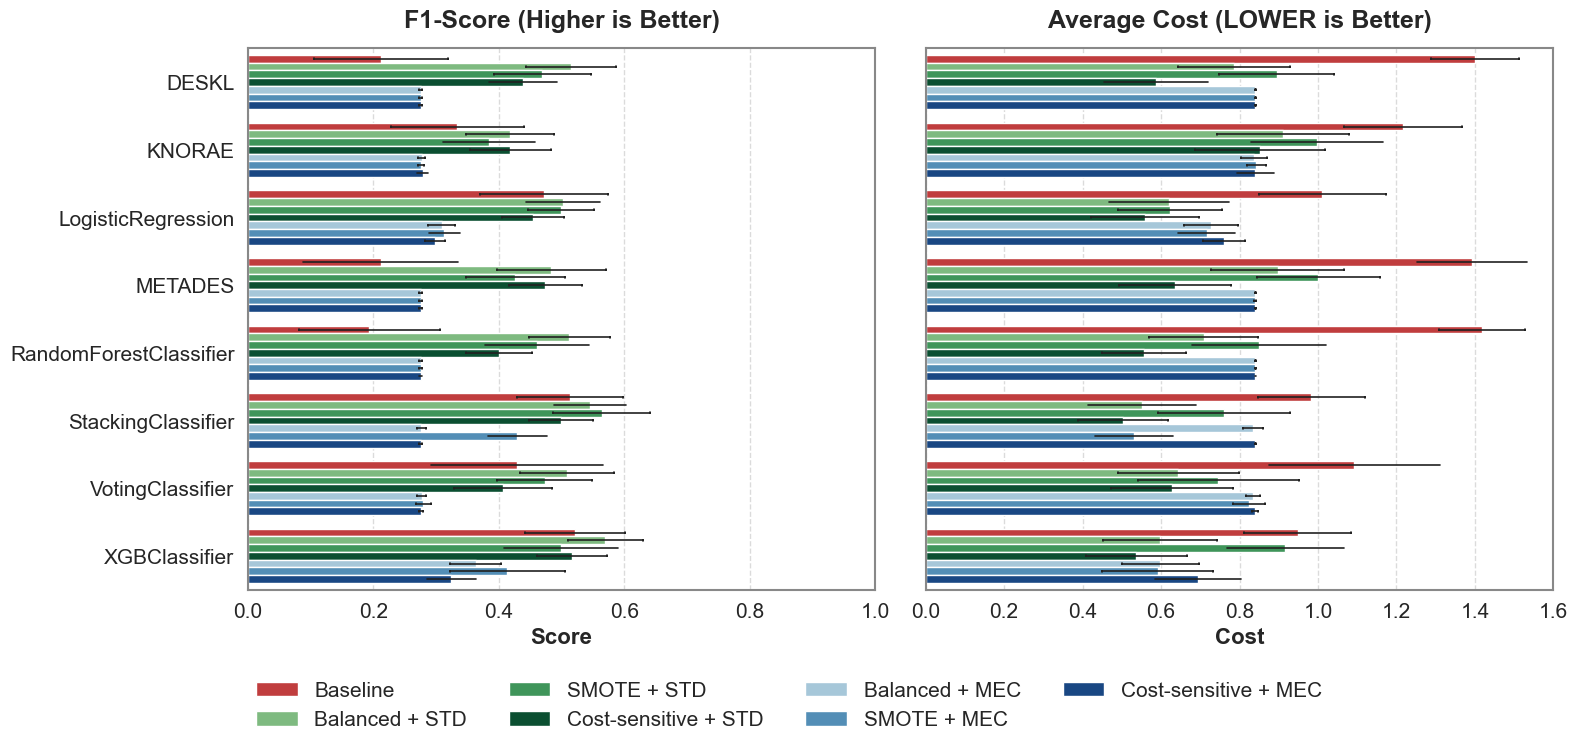

In [13]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

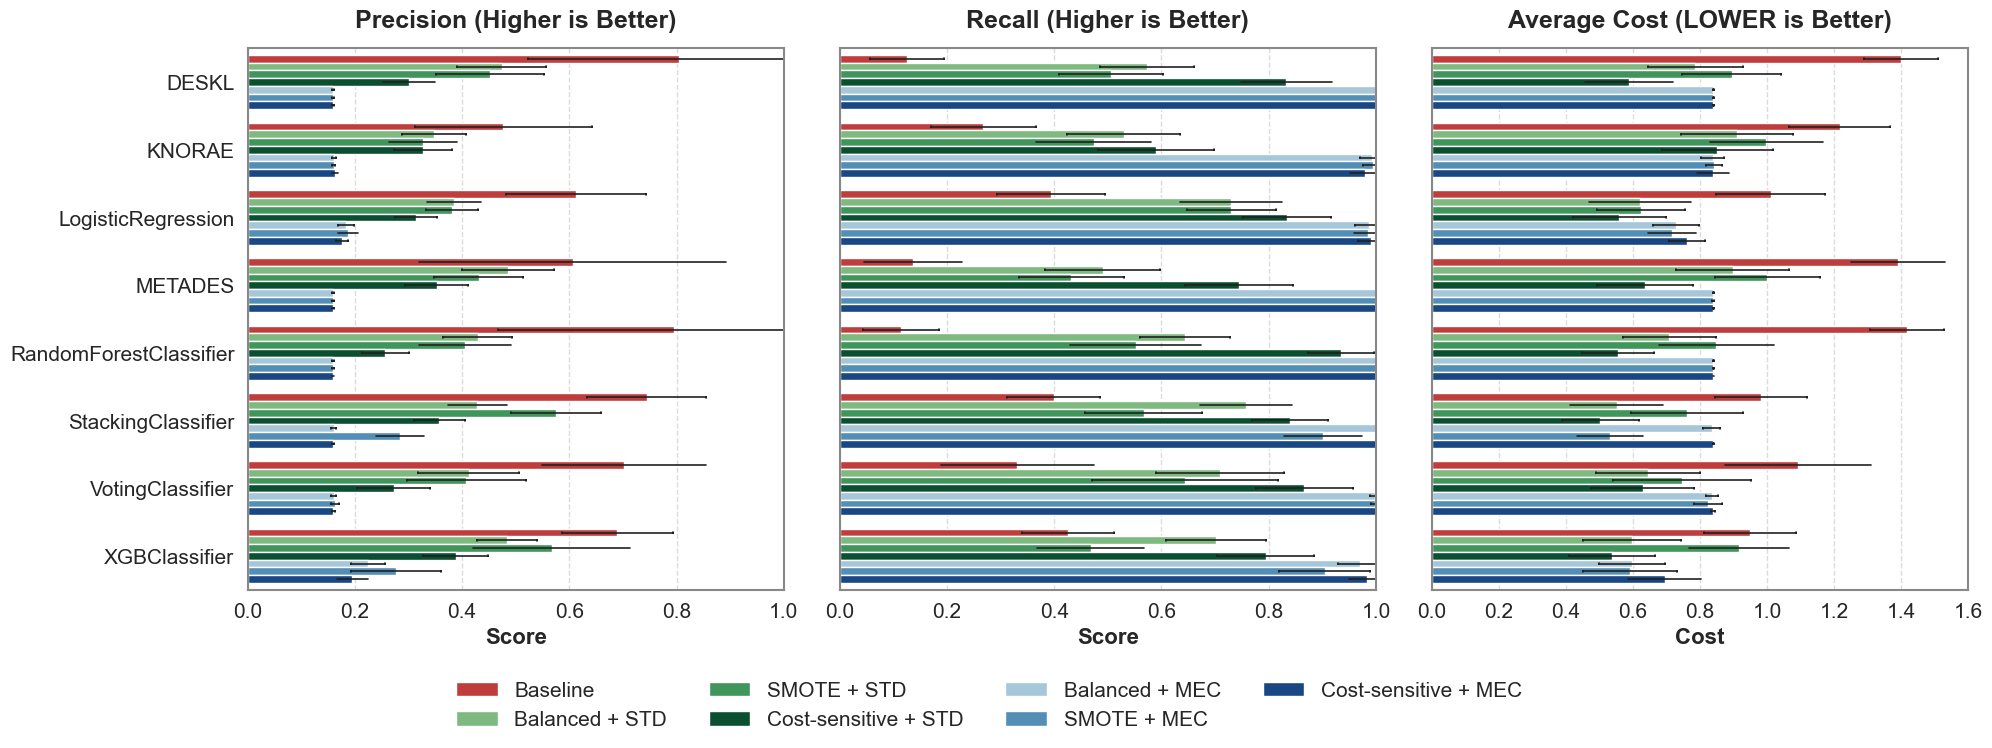

In [14]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 4: Models Family Comparison

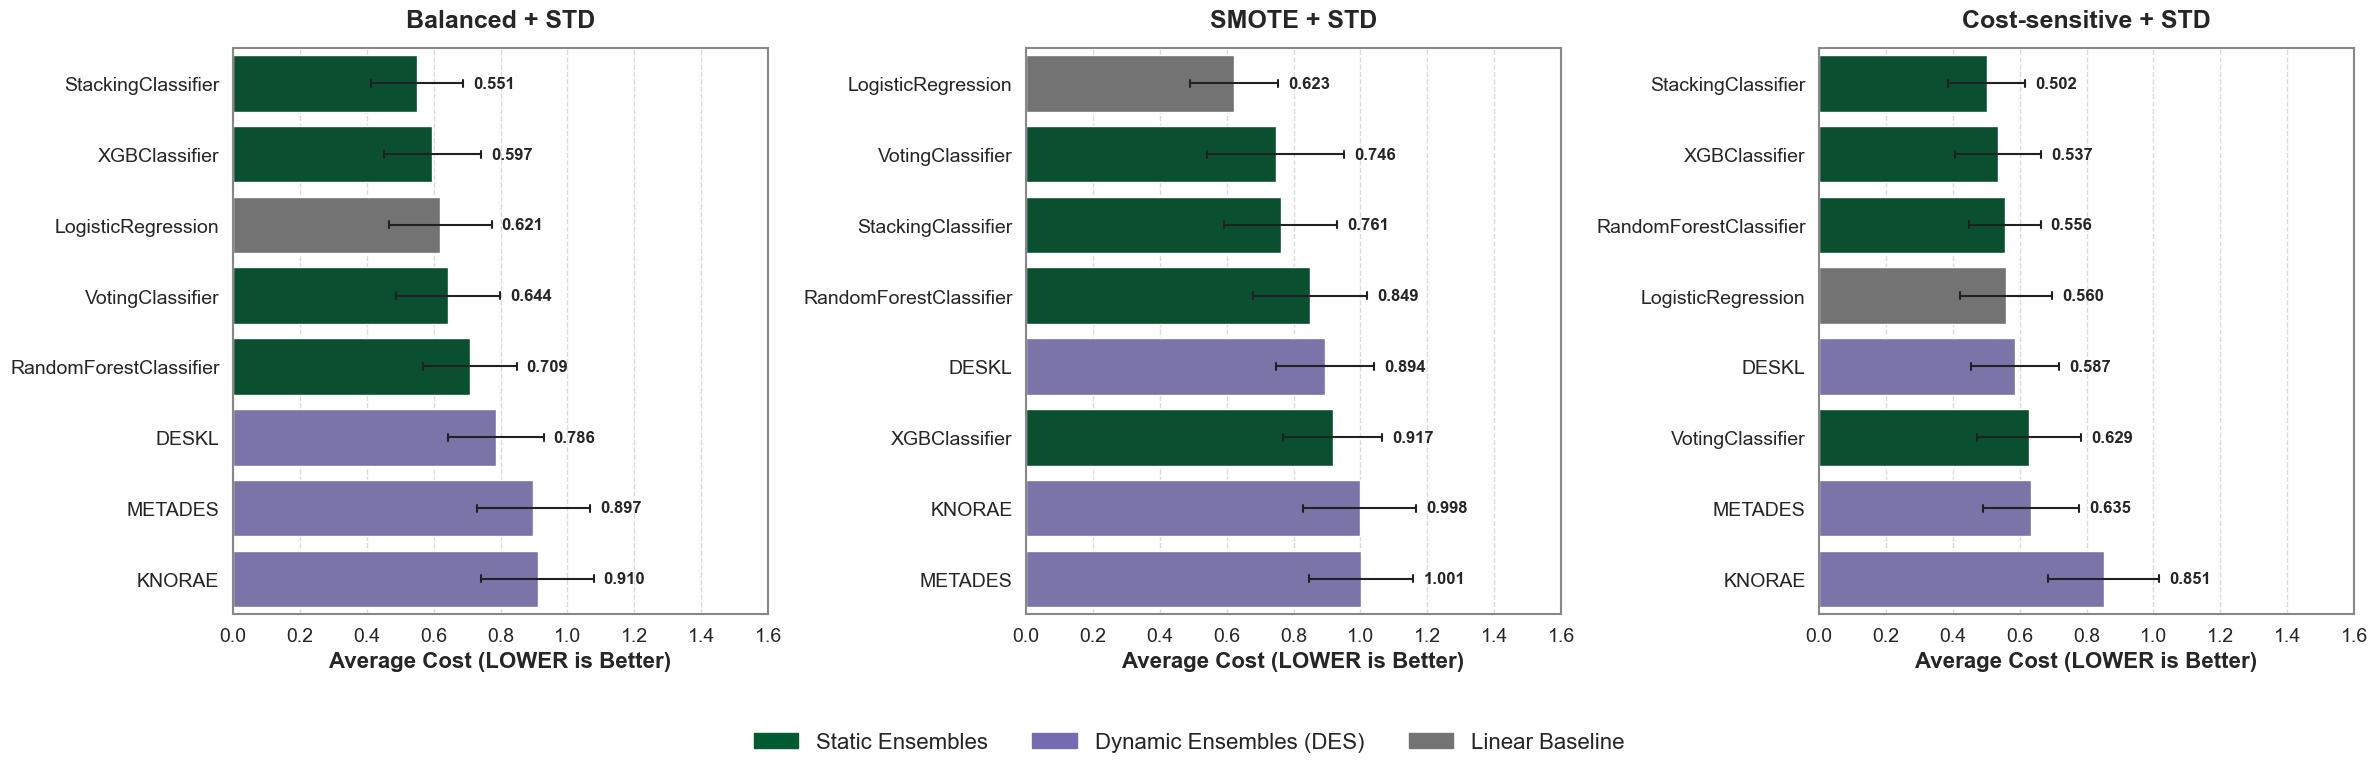

In [15]:
# Select the experiment to compare
experiments = {
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide4 = generalization_df[generalization_df['experiment_name'].isin(experiments.keys())].copy()

# Map each model to its family
def assign_family(model_name):
    if model_name in ['StackingClassifier', 'XGBClassifier', 'RandomForestClassifier', 'VotingClassifier']:
        return 'Static Ensembles'
    elif model_name in ['DESKL', 'METADES', 'KNORAE']:
        return 'Dynamic Ensembles (DES)'
    else:
        return 'Linear Baseline' # LogisticRegression

df_slide4['model_family'] = df_slide4['model_no_alias'].apply(assign_family)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8), sharey=False)

family_colors = {
    'Static Ensembles': '#005a32',           # Dark Green
    'Dynamic Ensembles (DES)': '#756bb1',    # Purple
    'Linear Baseline': '#737373'             # Grey
}

for i, (exp_key, exp_title) in enumerate(experiments.items()):
    ax = axes[i]
    df_exp = df_slide4[df_slide4['experiment_name'] == exp_key].copy()

    model_means = df_exp.groupby('model_no_alias')['average_cost'].mean().sort_values(ascending=True)
    model_order = model_means.index.tolist()

    sns.barplot(
        data=df_exp,
        x='average_cost',
        y='model_no_alias',
        hue='model_family',
        order=model_order,
        dodge=False,
        palette=family_colors,
        ax=ax,
        errorbar='sd',
        capsize=0.1,
        err_kws={'linewidth': 1.5, 'color': '#212121'}
    )

    ax.set_title(exp_title, fontweight="bold", pad=15)
    ax.set_xlabel("Average Cost (LOWER is Better)", fontweight="bold")
    ax.set_ylabel('')

    for idx, model in enumerate(model_order):
        mean_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].mean()
        std_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].std()

        ax.text(mean_val + std_val + 0.03, idx,
                f'{mean_val:.3f}',
                ha='left', va='center', fontweight='bold', fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_xlim(0, 1.6)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles = [plt.Rectangle((0,0),1,1, color=family_colors[label]) for label in family_colors.keys()]
fig.legend(handles, family_colors.keys(),
           loc="lower center", ncol=3, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide4_std_settings_static_des_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

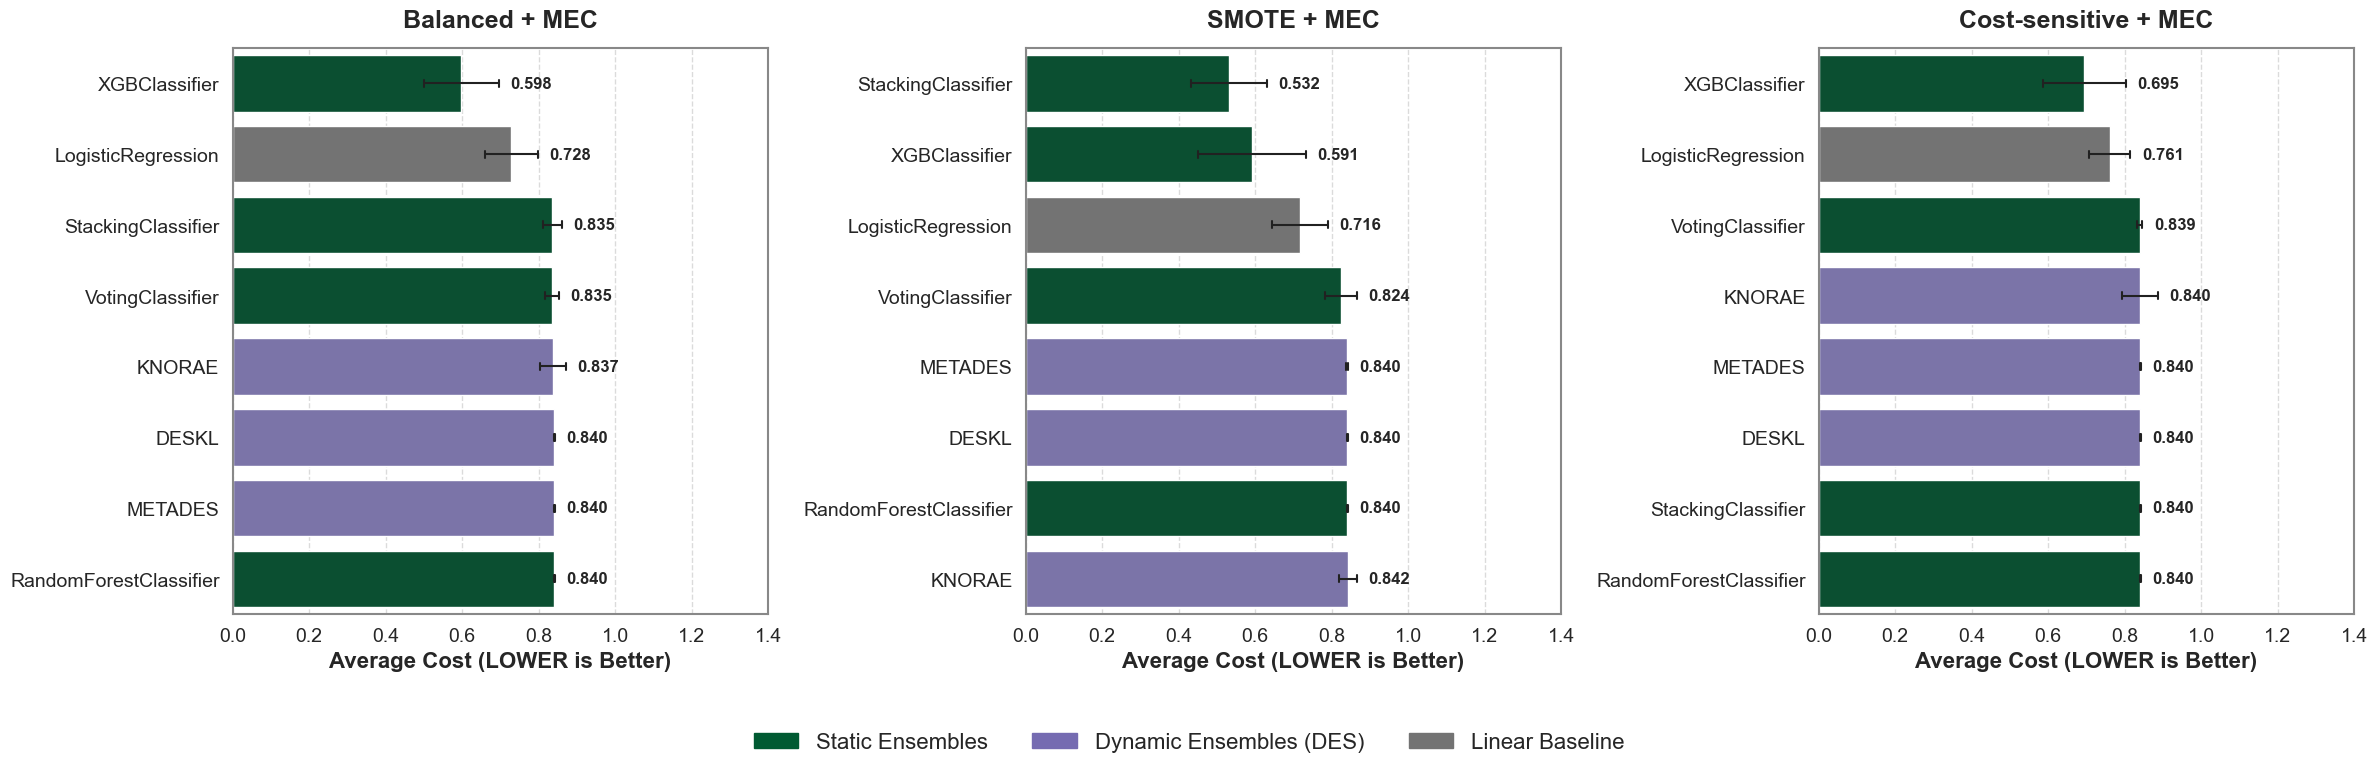

In [16]:
# Select the experiment to compare
experiments_mec = {
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide_mec = generalization_df[generalization_df['experiment_name'].isin(experiments_mec.keys())].copy()

# Map each model to its family
def assign_family(model_name):
    if model_name in ['StackingClassifier', 'XGBClassifier', 'RandomForestClassifier', 'VotingClassifier']:
        return 'Static Ensembles'
    elif model_name in ['DESKL', 'METADES', 'KNORAE']:
        return 'Dynamic Ensembles (DES)'
    else:
        return 'Linear Baseline' # LogisticRegression

df_slide_mec['model_family'] = df_slide_mec['model_no_alias'].apply(assign_family)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8), sharey=False)

family_colors = {
    'Static Ensembles': '#005a32',           # Dark Green
    'Dynamic Ensembles (DES)': '#756bb1',    # Purple
    'Linear Baseline': '#737373'             # Grey
}

for i, (exp_key, exp_title) in enumerate(experiments_mec.items()):
    ax = axes[i]
    df_exp = df_slide_mec[df_slide_mec['experiment_name'] == exp_key].copy()

    model_means = df_exp.groupby('model_no_alias')['average_cost'].mean().sort_values(ascending=True)
    model_order = model_means.index.tolist()

    sns.barplot(
        data=df_exp,
        x='average_cost',
        y='model_no_alias',
        hue='model_family',
        order=model_order,
        dodge=False,
        palette=family_colors,
        ax=ax,
        errorbar='sd',
        capsize=0.1,
        err_kws={'linewidth': 1.5, 'color': '#212121'}
    )

    ax.set_title(exp_title, fontweight="bold", pad=15)
    ax.set_xlabel("Average Cost (LOWER is Better)", fontweight="bold")
    ax.set_ylabel('')

    for idx, model in enumerate(model_order):
        mean_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].mean()
        std_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].std()

        ax.text(mean_val + std_val + 0.03, idx,
                f'{mean_val:.3f}',
                ha='left', va='center', fontweight='bold', fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_xlim(0, 1.4)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles = [plt.Rectangle((0,0),1,1, color=family_colors[label]) for label in family_colors.keys()]
fig.legend(handles, family_colors.keys(),
           loc="lower center", ncol=3, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide4_mec_settings_static_des_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()